In [ ]:
**Student:** Yara Mahmoud  
**ID:** 202300177  

This notebook visualizes samples from Waymo Open Dataset:
- LiDAR Range + Intensity images
- Front Camera image with projected 3D vehicle labels

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tools.waymo_reader.simple_waymo_open_dataset_reader import utils as waymo_utils
from tools.waymo_reader.simple_waymo_open_dataset_reader import WaymoDataFileReader, dataset_pb2
import misc.objdet_tools as tools
import student.objdet_pcl as pcl

In [2]:
data_filename = 'training_segment-1005081002024129653_5313_150_5333_150_with_camera_labels.tfrecord'
data_fullpath = os.path.join(os.getcwd(), 'dataset', data_filename)

datafile = WaymoDataFileReader(data_fullpath)
data_iter = iter(datafile)

frames_to_show = [0,1,2]

In [3]:
def show_img(img, title="", figsize=(12,6)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        # cv2 is BGR; matplotlib expects RGB
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

Frame: 0


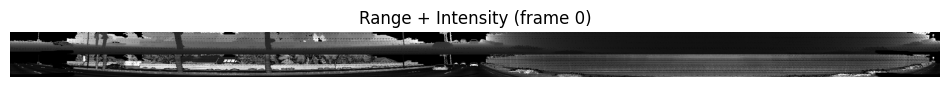

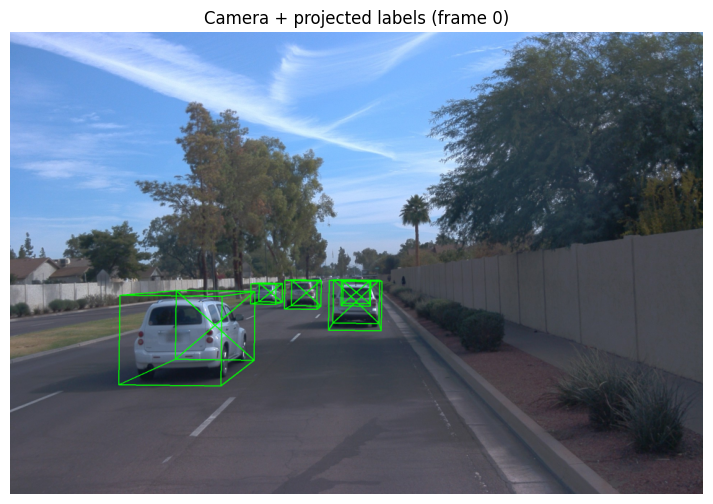

Frame: 1


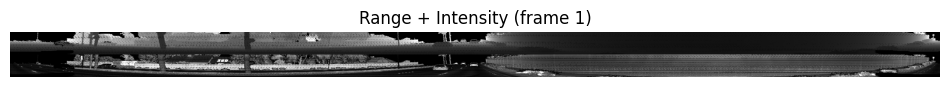

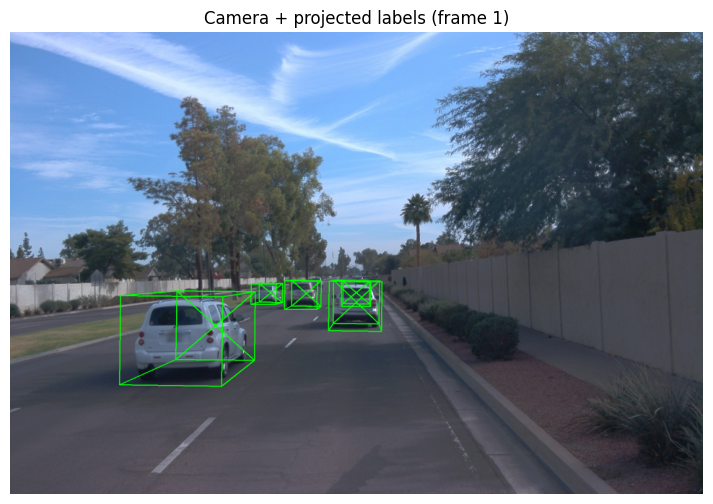

Frame: 2


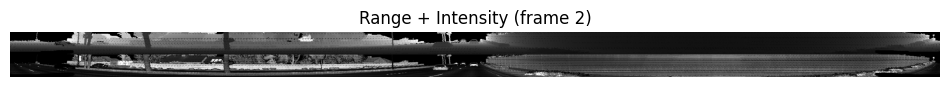

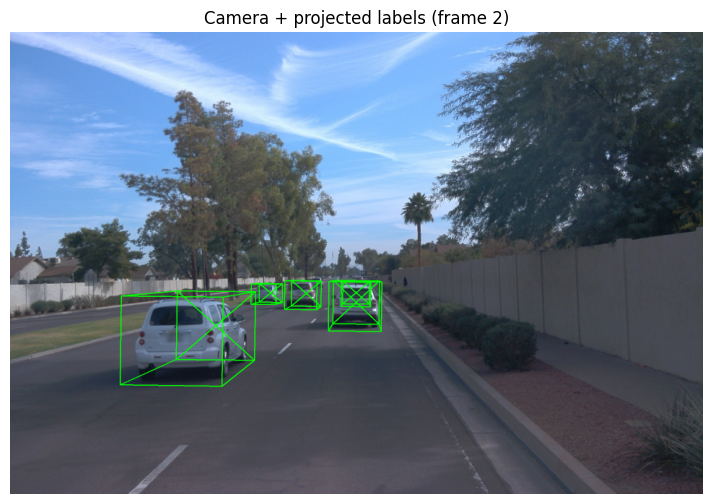

In [5]:
for idx in range(max(frames_to_show)+1):
    frame = next(data_iter)
    if idx not in frames_to_show:
        continue
    
    print("Frame:", idx)
    
    lidar_name  = dataset_pb2.LaserName.TOP
    camera_name = dataset_pb2.CameraName.FRONT
    
    camera_calib = waymo_utils.get(frame.context.camera_calibrations, camera_name)

    img_range = pcl.show_range_image(frame, lidar_name)
    show_img(img_range, title=f"Range + Intensity (frame {idx})", figsize=(12,8))

    image = tools.extract_front_camera_image(frame)

    valid_label_flags = [True] * len(frame.laser_labels) 
    img_labels = tools.project_labels_into_camera(camera_calib, image, frame.laser_labels, valid_label_flags, 0.5)
    show_img(img_labels, title=f"Camera + projected labels (frame {idx})", figsize=(12,6))

In [ ]:
## Observations

- The LiDAR **range + intensity** view shows a panoramic “strip” representation: the top part corresponds to **range (depth)** and the bottom part corresponds to **intensity (reflectivity)**. You can notice changes in brightness where objects are closer/farther or have different surface materials.
- In the **camera image with projected 3D labels**, nearby vehicles appear with **larger bounding boxes**, while distant vehicles have **smaller boxes** due to perspective and distance.
- Some projected boxes may look slightly misaligned or partially off the object edges. This is expected because the projection depends on **sensor calibration (intrinsics/extrinsics)** and the exact synchronization between sensors.
- The range image often shows **banding/scan-line patterns** because LiDAR measures the scene with discrete vertical beams and a rotating sensor, so the sampling is not uniform like an image.
- Occlusions are visible in the camera view (e.g., vehicles partially hidden), which can make labeling/projection harder compared to LiDAR where depth helps separate foreground/background.
- Overall, LiDAR provides strong **geometric (3D) information**, while the camera provides rich **appearance (color/texture) information**—and combining them supports more reliable perception.